# Lung Cancer Classification Using Deep Learning

## Overview
This notebook presents a deep learning-based framework for automated classification of lung CT scan images into **Benign**, **Malignant**, and **Normal** categories using the IQ-OTHNCCD dataset.

Multiple architectures are implemented and compared, including:
- Custom CNN
- Transfer Learning with EfficientNetB0
- Fine-Tuned EfficientNetB0

Performance is evaluated using classification metrics, confusion matrices, and ROC-AUC analysis.

## Importing Required Libraries
The necessary libraries for image preprocessing, model development, visualization, and evaluation are imported.

In [22]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout ,BatchNormalization
from tensorflow.keras import regularizers
import cv2 
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import  ReduceLROnPlateau
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd

In [3]:
print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow Version: 2.19.0
Num GPUs Available: 2


## Loading Dataset
CT scan images are loaded from class-specific directories and converted into NumPy arrays for downstream preprocessing and model training.

In [4]:
def load_images_from_dir(directory, label):
    images = []
    labels = []
    for filename in os.listdir(directory):
        if filename.endswith(".jpg") or filename.endswith(".png"): 
            img_path = os.path.join(directory, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (128, 128))
                images.append(img)
                labels.append(label)
    return images, labels

In [9]:
benign_dir = r"/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases"
malignant_dir = r"/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases"
normal_dir = r"/kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases"

In [10]:
benign_images, benign_labels = load_images_from_dir(benign_dir, label=0)  
malignant_images, malignant_labels = load_images_from_dir(malignant_dir, label=1)  
normal_images, normal_labels = load_images_from_dir(normal_dir, label=2)  

In [11]:
images = benign_images + malignant_images + normal_images
labels = benign_labels + malignant_labels + normal_labels

In [14]:
images = np.array(images)
labels = np.array(labels)

In [49]:
X_train, X_valid, y_train, y_valid = train_test_split(images, labels, test_size=0.2, random_state=42)

## Sample Image Visualization
Random samples from each category are displayed to inspect dataset characteristics and verify image loading.

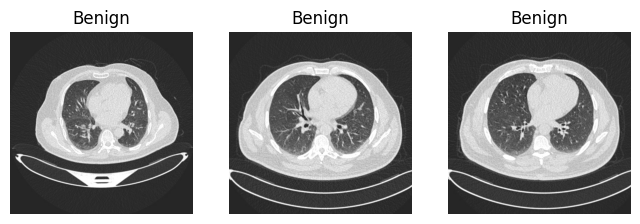

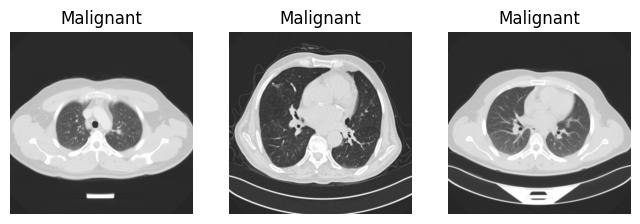

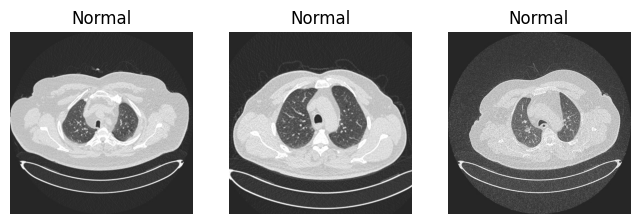

In [19]:
categories = {
    "Benign": benign_dir,
    "Malignant": malignant_dir,
    "Normal": normal_dir
}

for category, image_dir in categories.items():
    image_paths = [os.path.join(image_dir, filename) for filename in os.listdir(image_dir) if filename.endswith(('.jpg', '.png'))]
    fig, ax = plt.subplots(1, 3, figsize=(8, 8))
    ax = ax.ravel()
    
    for i, img_path in enumerate(np.random.choice(image_paths, size=3, replace=False)):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
        ax[i].imshow(img)
        ax[i].axis("off")
        ax[i].set_title(category)
    
    plt.show()

In [23]:
count_data = pd.DataFrame({
    "label": ["Benign", "Malignant", "Normal"],
    "count": [len(benign_images), len(malignant_images), len(normal_images)]
})

## Model 1: Custom CNN Baseline
A baseline convolutional neural network is implemented to establish benchmark performance.

In [25]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  
])

In [26]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer= optimizer,
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [28]:
from tensorflow.keras.utils import to_categorical

In [29]:
y_train_encoded = to_categorical(y_train, num_classes=3)
y_valid_encoded = to_categorical(y_valid, num_classes=3)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train_encoded:", y_train_encoded.shape)


Shape of X_train: (877, 128, 128)
Shape of y_train_encoded: (877, 3)


In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,779 (49.36 MB)

 Trainable params: 12,939,779 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    X_train, y_train_encoded,
    batch_size=32,
    validation_split=0.2,
    epochs=20,
    verbose = 1
)


Epoch 1/20


I0000 00:00:1776333236.986353     209 service.cc:152] XLA service 0x7aa9400050d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776333236.986393     209 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776333236.986397     209 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776333237.414617     209 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-16 09:53:59.222150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 09:53:59.369681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 7/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3808 - loss: 216.6917

I0000 00:00:1776333241.700272     209 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 247ms/step - accuracy: 0.4415 - loss: 118.3985 - val_accuracy: 0.7557 - val_loss: 0.6651
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7532 - loss: 0.6471 - val_accuracy: 0.9034 - val_loss: 0.2871
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9070 - loss: 0.2649 - val_accuracy: 0.9318 - val_loss: 0.1948
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9564 - loss: 0.1539 - val_accuracy: 0.9886 - val_loss: 0.0748
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9858 - loss: 0.0618 - val_accuracy: 0.9943 - val_loss: 0.0246
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9820 - loss: 0.0557 - val_accuracy: 0.9886 - val_loss: 0.0338
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9866 - loss: 0.0366 - val_accuracy: 0.9602 - val_loss: 0.1662
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9867 - loss: 0.0370 - val_accuracy: 0.9830 - val_loss

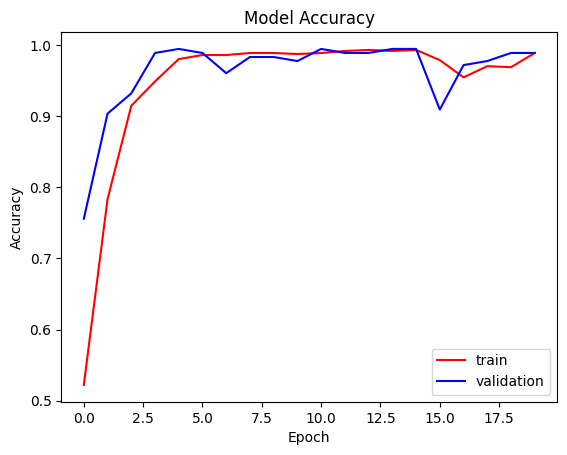

In [33]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Generating predictions on validation set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      Benign       1.00      0.86      0.93        29
   Malignant       0.99      0.99      0.99       109
      Normal       0.95      1.00      0.98        82

    accuracy                           0.98       220
   macro avg       0.98      0.95      0.96       220
weighted avg       0.98      0.98      0.98       220



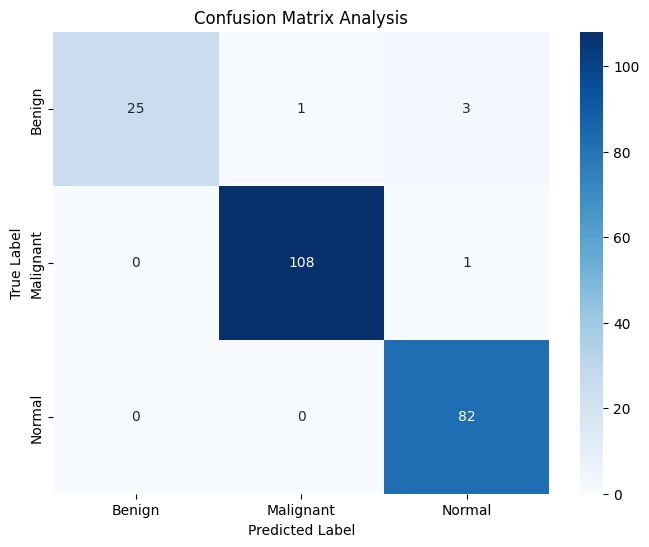

In [71]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

active_model = model
print("Generating predictions on validation set...")
y_pred = active_model.predict(X_valid, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = y_valid
class_names = ["Benign", "Malignant", "Normal"]

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Analysis')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

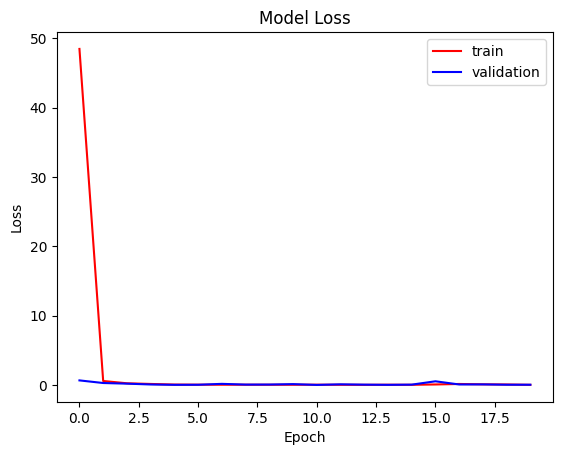

In [34]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [41]:
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {train_accuracy:.4f}")
print(f"Final Validation Accuracy: {val_accuracy:.4f}")
print(f"Final Training Loss: {train_loss:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")

Final Training Accuracy: 0.9886
Final Validation Accuracy: 0.9886
Final Training Loss: 0.0256
Final Validation Loss: 0.0399


## Model 2: Transfer Learning with EfficientNetB0
EfficientNetB0 pretrained on ImageNet is used as a feature extractor with a custom classification head.

In [57]:
from tensorflow.keras.applications import EfficientNetB7 , EfficientNetB0
from tensorflow.keras import layers, models

In [58]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3),
    classes = 3 
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [59]:
model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(3, activation='softmax') 
])

In [60]:
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,438 (16.08 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

In [62]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Preprocessing for Transfer Learning
Images are resized, converted to RGB, and preprocessed according to EfficientNetB0 input requirements.

In [63]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess_for_efficientnet(X):
    processed = []
    
    for img in X:
        img = cv2.resize(img, (256, 256))
        
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[-1] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        processed.append(img)
    
    processed = np.array(processed, dtype=np.float32)
    return preprocess_input(processed)

X_train_eff = preprocess_for_efficientnet(X_train)
X_valid_eff  = preprocess_for_efficientnet(X_valid)

In [64]:
from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train, num_classes=3)
y_valid_encoded  = to_categorical(y_valid, num_classes=3)

In [65]:
history = model2.fit(
    X_train_eff,
    y_train_encoded,
    validation_data=(X_test_eff, y_test_encoded),
    epochs=20,
    batch_size=8,
    verbose=1
)

Epoch 1/20


2026-04-16 10:24:50.481204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:24:50.619083: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:24:50.931589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:24:51.071646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:24:51.868920: E external/local_xla/xla/stream_

107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4686 - loss: 1.1437

2026-04-16 10:25:07.471656: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:07.607248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:07.933438: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:08.077506: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:08.893132: E external/local_xla/xla/stream_

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4717 - loss: 1.1380

2026-04-16 10:25:28.302045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:28.436600: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:28.767519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:28.907801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 10:25:29.047969: E external/local_xla/xla/stream_

110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 319ms/step - accuracy: 0.4727 - loss: 1.1361 - val_accuracy: 0.8227 - val_loss: 0.6117
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6918 - loss: 0.7050 - val_accuracy: 0.8591 - val_loss: 0.4439
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7879 - loss: 0.5185 - val_accuracy: 0.8591 - val_loss: 0.4110
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8047 - loss: 0.4817 - val_accuracy: 0.8727 - val_loss: 0.3586
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8042 - loss: 0.4927 - val_accuracy: 0.8773 - val_loss: 0.3464
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8172 - loss: 0.4536 - val_accuracy: 0.8818 - val_loss: 0.3081
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7991 - loss: 0.4813 - val_accuracy: 0.8909 - val_loss: 0.3067
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8423 - loss: 0.4130 - val_accuracy: 0.8

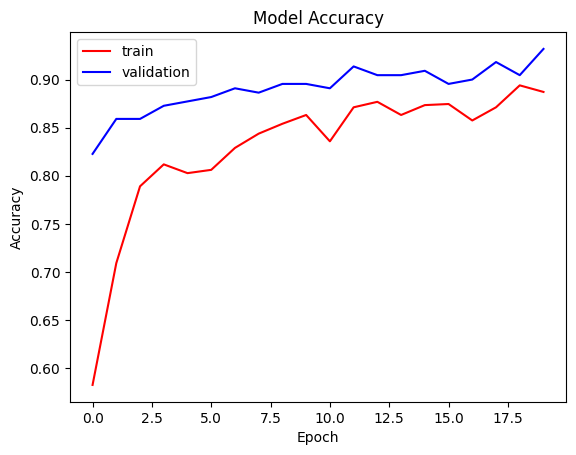

In [66]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

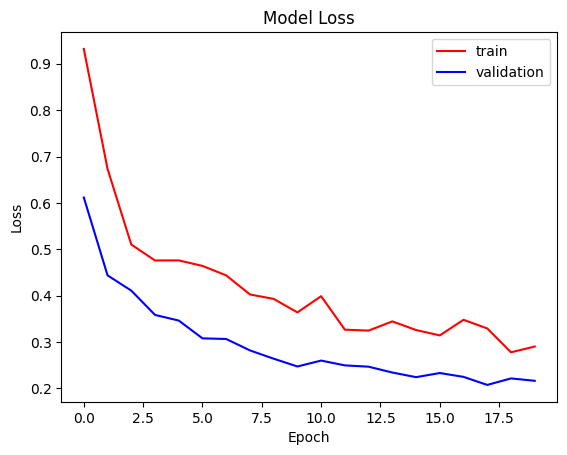

In [67]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Generating predictions on validation set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      Benign       0.80      0.69      0.74        29
   Malignant       0.98      1.00      0.99       109
      Normal       0.90      0.93      0.92        82

    accuracy                           0.93       220
   macro avg       0.90      0.87      0.88       220
weighted avg       0.93      0.93      0.93       220



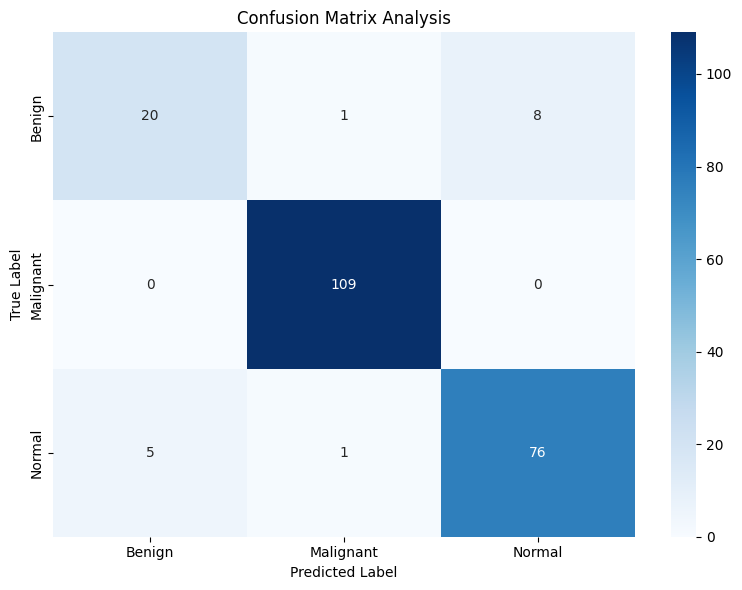

In [72]:
active_model = model2

print("Generating predictions on validation set...")

y_pred_probs = active_model.predict(X_valid_eff, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true = y_valid
class_names = ["Benign", "Malignant", "Normal"]

print("\n--- Classification Report ---")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix Analysis")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Model 3: Fine-Tuned EfficientNetB0
The pretrained EfficientNetB0 backbone is partially unfrozen for fine-tuning
to improve task-specific performance.

## Data Augmentation
Online augmentation is applied during training to improve generalization and reduce overfitting.

In [94]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.1)
])

In [96]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

In [97]:
base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model3 = models.Sequential([
    data_augmentation,   
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

In [98]:
model3.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 3,840,348 (14.65 MB)

 Non-trainable params: 209,223 (817.28 KB)

In [99]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [100]:
checkpoint_callback = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [101]:
history = model3.fit(
    X_train_eff,
    y_train_encoded,
    validation_data=(X_valid_eff, y_valid_encoded),
    epochs=40,
    batch_size=16,
    callbacks=[
        checkpoint_callback,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/40


E0000 00:00:1776338682.302577      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_7_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5327 - loss: 1.2660
Epoch 1: val_accuracy improved from -inf to 0.68182, saving model to best_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 44s 238ms/step - accuracy: 0.5350 - loss: 1.2598 - val_accuracy: 0.6818 - val_loss: 0.8378 - learning_rate: 1.0000e-04
Epoch 2/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7813 - loss: 0.5621
Epoch 2: val_accuracy did not improve from 0.68182
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.7816 - loss: 0.5617 - val_accuracy: 0.6455 - val_loss: 0.7732 - learning_rate: 1.0000e-04
Epoch 3/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7861 - loss: 0.5582
Epoch 3: val_accuracy improved from 0.68182 to 0.70909, saving model to best_model.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.7866 - loss: 0.5572 - val_accuracy: 0.7091 - val_loss: 0.6922 - learning_rate: 1.0000e-04
Epoch 4/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8760 - loss: 0.3535
Epoch

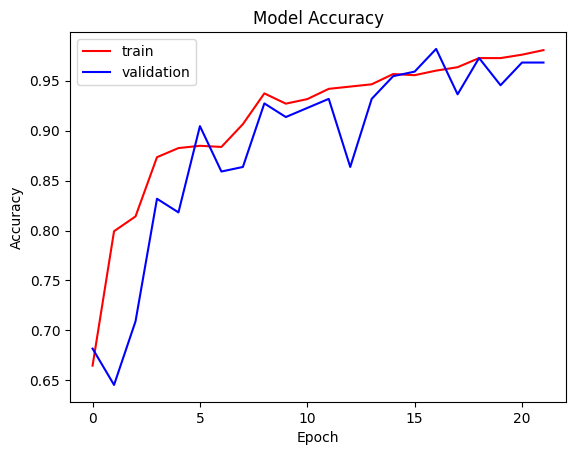

In [102]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history
         ['val_accuracy'],color='blue',label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

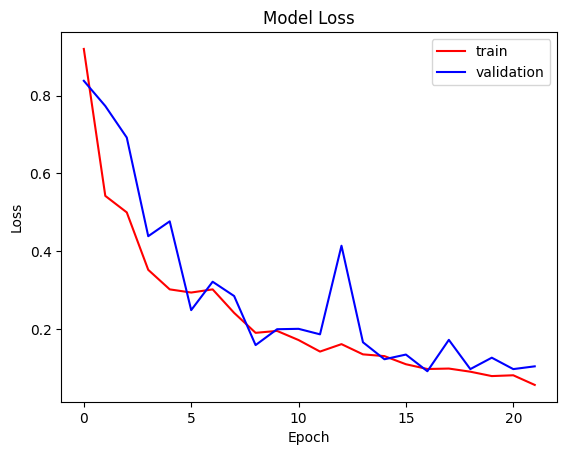

In [103]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Generating predictions on validation set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 547ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93        29
   Malignant       1.00      1.00      1.00       109
      Normal       0.98      0.98      0.98        82

    accuracy                           0.98       220
   macro avg       0.97      0.97      0.97       220
weighted avg       0.98      0.98      0.98       220



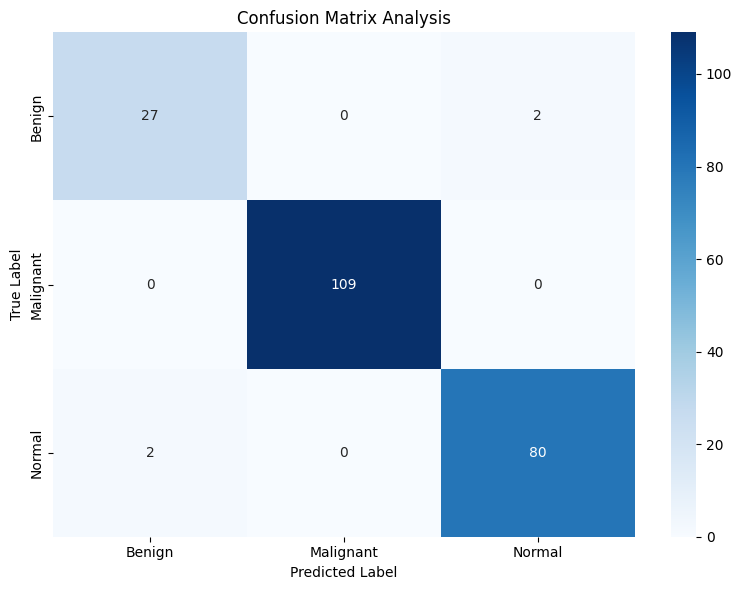

In [104]:
active_model = model3

print("Generating predictions on validation set...")

y_pred_probs = active_model.predict(X_valid_eff, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true = y_valid
class_names = ["Benign", "Malignant", "Normal"]

print("\n--- Classification Report ---")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix Analysis")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Comparative Performance Analysis
Performance of all models is compared to determine the most effective architecture.

In [105]:
def evaluate_model(model, X, y_true, model_name):
    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1 Score": f1_score(y_true, y_pred, average='weighted')
    }

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [107]:
results = []

results.append(evaluate_model(model, X_valid, y_valid, "Custom CNN"))
results.append(evaluate_model(model2, X_valid_eff, y_valid, "EfficientNetB0"))
results.append(evaluate_model(model3, X_valid_eff, y_valid, "Fine-Tuned EfficientNetB7"))

comparison_df = pd.DataFrame(results)
print(comparison_df)

                       Model  Accuracy  Precision    Recall  F1 Score
0                 Custom CNN  0.977273   0.978118  0.977273  0.976816
1             EfficientNetB0  0.931818   0.929211  0.931818  0.929886
2  Fine-Tuned EfficientNetB7  0.981818   0.981818  0.981818  0.981818


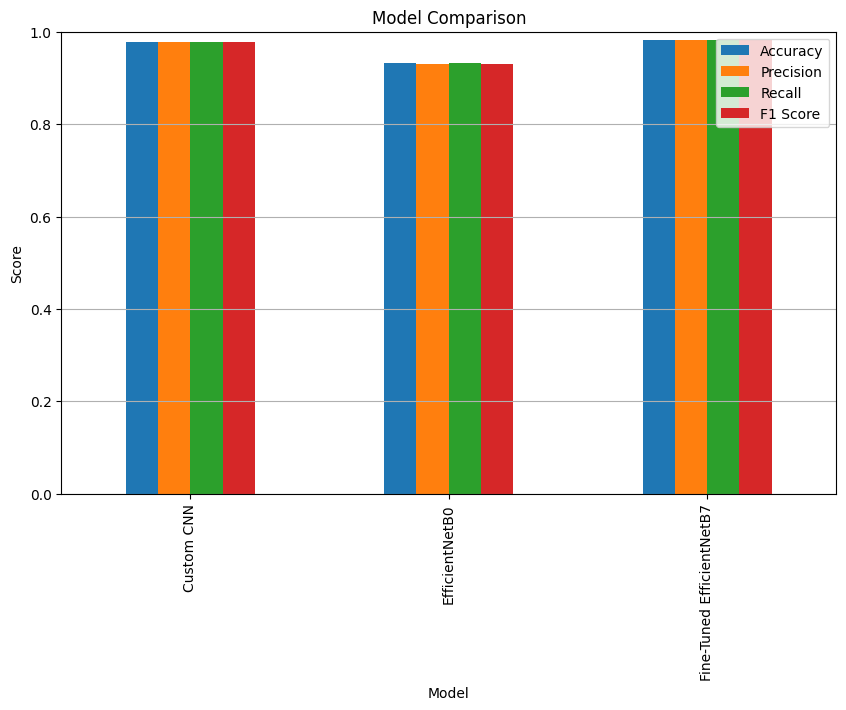

In [108]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

In [109]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [110]:
y_valid_bin = label_binarize(y_valid, classes=[0, 1, 2])

In [111]:
y_pred_probs = model3.predict(X_valid_eff)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


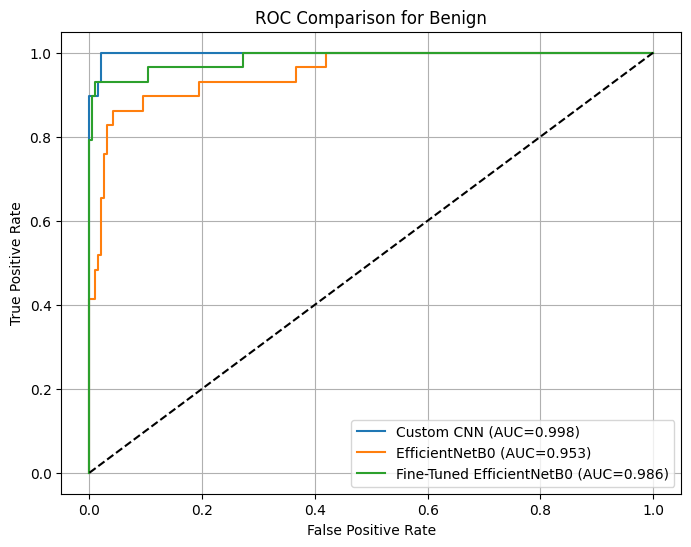

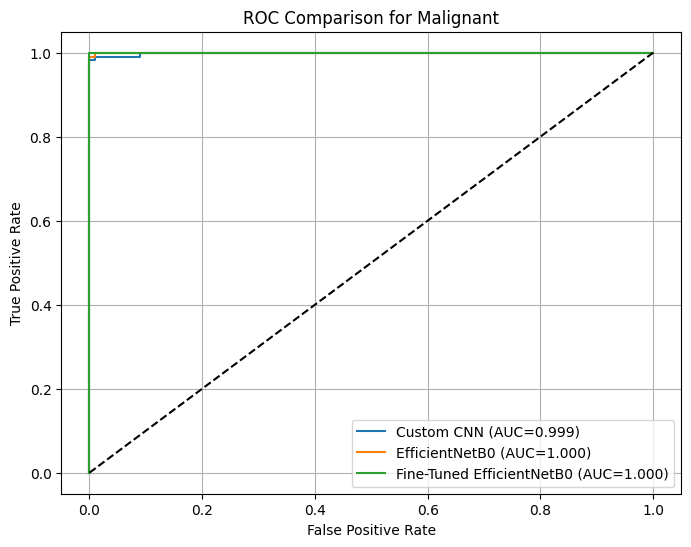

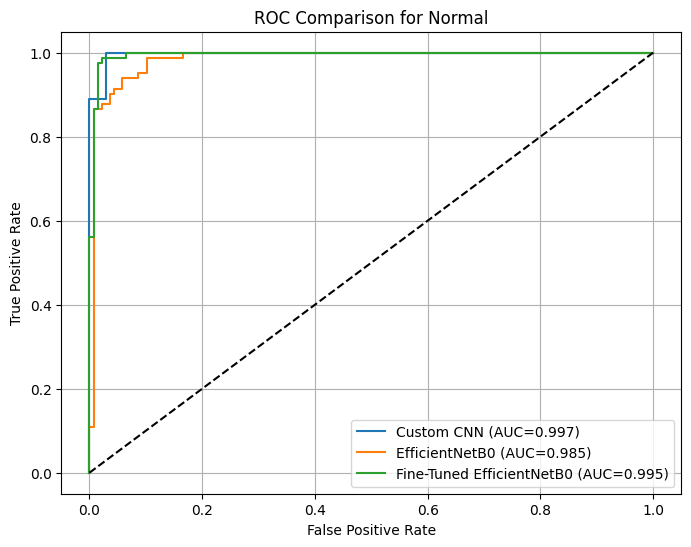

In [113]:
y_valid_bin = label_binarize(y_valid, classes=[0, 1, 2])

models_dict = {
    "Custom CNN": (model, X_valid),
    "EfficientNetB0": (model2, X_valid_eff),
    "Fine-Tuned EfficientNetB0": (model3, X_valid_eff)
}

class_names = ["Benign", "Malignant", "Normal"]

for class_idx in range(3):

    plt.figure(figsize=(8,6))

    for model_name, (mdl, X_input) in models_dict.items():

        y_pred_probs = mdl.predict(X_input, verbose=0)

        fpr, tpr, _ = roc_curve(
            y_valid_bin[:, class_idx],
            y_pred_probs[:, class_idx]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{model_name} (AUC={roc_auc:.3f})"
        )

    plt.plot([0,1], [0,1], 'k--')

    plt.title(f"ROC Comparison for {class_names[class_idx]}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()